<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 6.4
# *PCA Lab*

**In this lab, we will:**
- Explore how PCA is related to correlation.
- Use PCA to perform dimensionality reduction.

### 1. Load Data

Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. They describe characteristics of the cell nuclei present in the image. n the 3-dimensional space is that described in: [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

This database is also available through the UW CS ftp server: ftp ftp.cs.wisc.edu cd math-prog/cpo-dataset/machine-learn/WDBC/

Also can be found on UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29

Attribute Information:

1) ID number 2) Diagnosis (M = malignant, B = benign) 3-32)

Ten real-valued features are computed for each cell nucleus:

a) radius (mean of distances from center to points on the perimeter) b) texture (standard deviation of gray-scale values) c) perimeter d) area e) smoothness (local variation in radius lengths) f) compactness (perimeter^2 / area - 1.0) g) concavity (severity of concave portions of the contour) h) concave points (number of concave portions of the contour) i) symmetry j) fractal dimension ("coastline approximation" - 1)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.

All feature values are recoded with four significant digits.

Missing attribute values: none

Class distribution: 357 benign, 212 malignant

In [1]:
import numpy as np
import pandas as pd

# The clustering muscle
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# The visualization duo
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

In [4]:
breast_cancer_csv = 'breast-cancer-wisconsin-data.csv'
df = pd.read_csv(breast_cancer_csv)
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


### 2. EDA

Explore dataset. Clean data. Find correlation.

In [5]:
df_cleaned = df.drop(columns=['Unnamed: 32', 'id'])

# 2. Encode the categorical 'diagnosis' column
# M (Malignant) -> 1, B (Benign) -> 0
df_cleaned['diagnosis'] = df_cleaned['diagnosis'].map({'M': 1, 'B': 0})

# 3. Save the cleaned data to a new CSV file
df_cleaned.to_csv('cleaned_breast_cancer_data.csv', index=False)

# Display the first few rows of the cleaned data
print(df_cleaned.head())

   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          

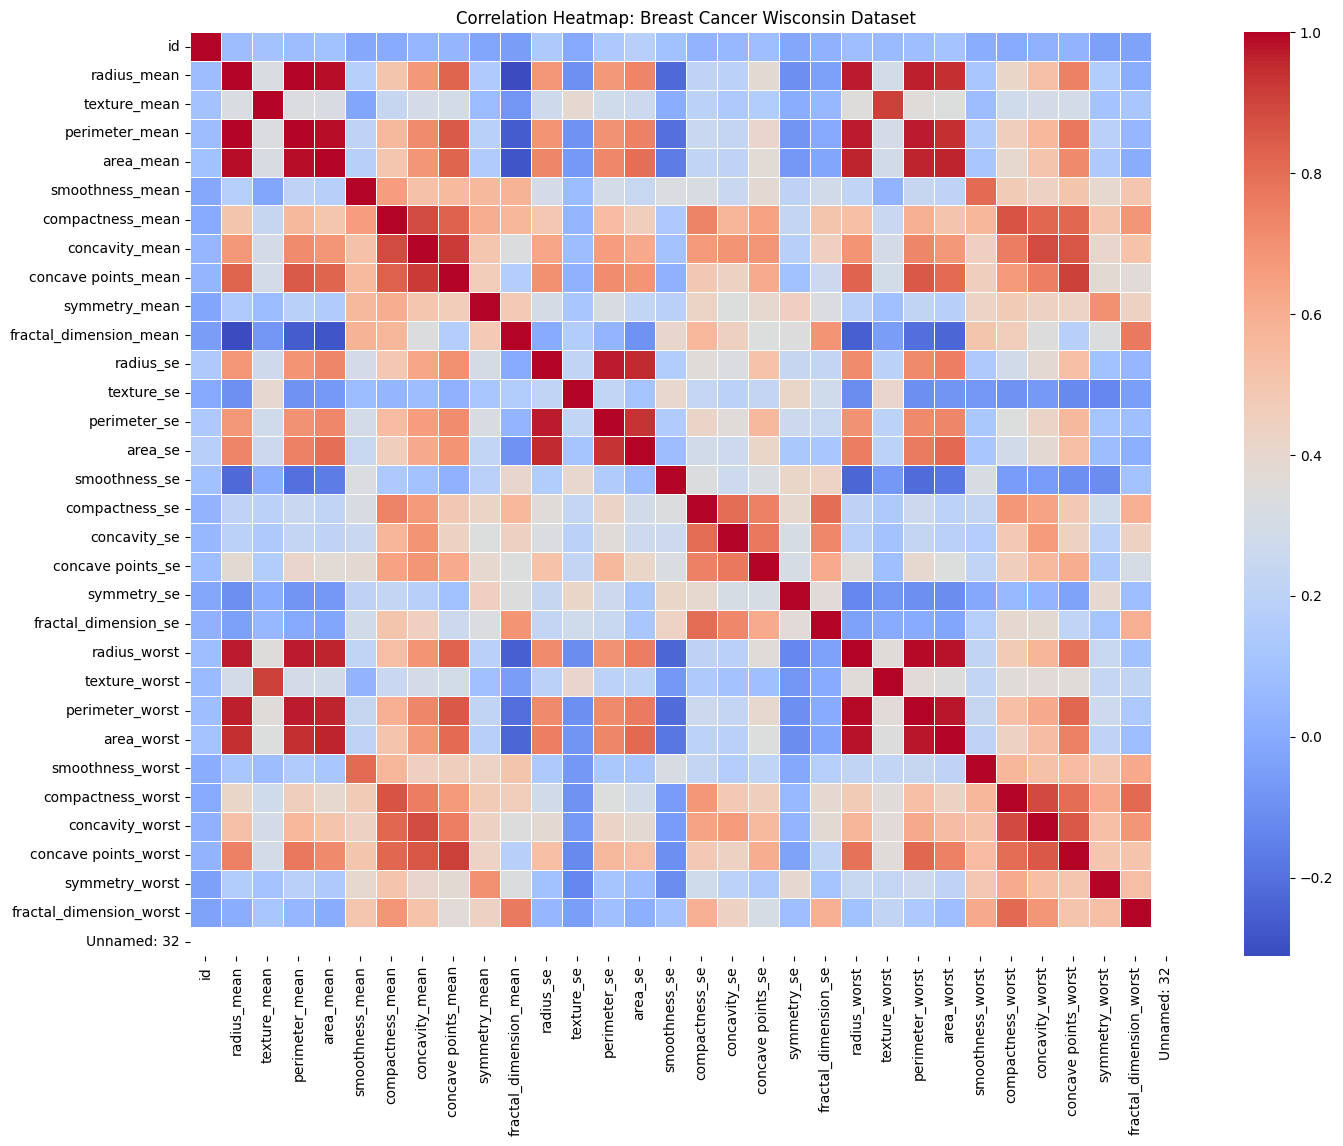

In [7]:
X = df.drop(columns=['diagnosis'])

corr_matrix = X.corr()

# 3. Create the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=False, # Set to True to see the exact numbers
            cmap='coolwarm', 
            linewidths=0.5)

plt.title('Correlation Heatmap: Breast Cancer Wisconsin Dataset')
plt.show()

### 3. Subset & Normalize

Subset the data to only include all columns except diagnosis, then apply StandardScaler.

In [8]:
# Load the cleaned dataset
df_cleaned = pd.read_csv('cleaned_breast_cancer_data.csv')

# 1. Subset the data: include all columns except 'diagnosis'
X = df_cleaned.drop(columns=['diagnosis'])

# 2. Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Convert back to a DataFrame for easier inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first 5 rows of the scaled features
print(X_scaled_df.head())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

### Calculate correlation matrix

We will be using the correlation matrix to calculate the eigenvectors and eigenvalues.

In [9]:
corr_matrix = X_scaled_df.corr()

# 2. Compute Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(corr_matrix)

# Sort them by eigenvalue in descending order
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

### 4. Calculate the eigenvalues and eigenvectors from the correlation matrix

numpy has a convenient function to calculate this:

    eigenvalues, eigenvectors = np.linalg.eig(correlation_matrix)

In [10]:
loadings = eigenvectors * np.sqrt(eigenvalues)

# Display the loading matrix for the first 5 components
loadings_df = pd.DataFrame(loadings, index=X.columns, columns=[f'PC{i+1}' for i in range(len(eigenvalues))])
print(loadings_df.iloc[:, :5].head())

                      PC1       PC2       PC3       PC4       PC5
radius_mean      0.797767 -0.557903 -0.014321  0.058277 -0.048519
texture_mean     0.378013 -0.142438  0.108358 -0.848704  0.063519
perimeter_mean   0.829236 -0.513349 -0.015636  0.059085 -0.047990
area_mean        0.805393 -0.551270  0.048177  0.075200 -0.013266
smoothness_mean  0.519653  0.444002 -0.175072  0.224308  0.468784


### 5. Calculate and plot the cumulative explained variance

A useful measure is the **explained variance**, which is calculated from the eigenvalues.

The explained variance tells us how much information (variance) is captured by each principal component.

### $$ ExpVar_i (\%)= \bigg(\frac{eigenvalue_i}{\sum_{j=1}^n{eigenvalue_j}}\bigg) \times 100$$

In [ ]:
def calculate_cum_var_exp(eig_vals):
    '''
    Calculate cumulative explained variance from eigenvalues sorted in descending order

    Return a list or array containing the cumulative explained variance
    '''

    return cum_var_exp

In [ ]:
def plot_var_exp(eig_vals):

    cum_var_exp = calculate_cum_var_exp(eig_vals)

    plt.figure(figsize=(9,7))

    component_number = [i+1 for i in range(len(cum_var_exp))]

    plt.plot(component_number, cum_var_exp, lw=7)

    plt.axhline(y=0, linewidth=5, color='grey', ls='dashed')
    plt.axhline(y=100, linewidth=3, color='grey', ls='dashed')

    ax = plt.gca()
    ax.set_xlim([1,30])
    ax.set_ylim([-5,105])

    ax.set_ylabel('cumulative variance explained', fontsize=16)
    ax.set_xlabel('component', fontsize=16)

    for tick in ax.xaxis.get_major_ticks():
        tick.label1.set_fontsize(12)

    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(12)

    ax.set_title('component vs cumulative variance explained\n', fontsize=20)

    plt.show()

### 6. Using sklearn For PCA

    from sklearn.decomposition import PCA
    
- Create an instance of PCA
    - Fit X
- Plot the cumulative explained variance
- Apply dimensionality reduction to X with n_components=16
    - Fit and transform X
- Create a pairplot of PCA-transformed data

In [ ]:
# ANSWER
# Create an instance of PCA (do not set n_components)

# Fit Xs (breast cancer dataset having standardized features)


In [ ]:
# ANSWER
# Plot cumulative variance explained vs number of components using the plot_var_exp function from above


In [ ]:
# ANSWER
# Create another instance of PCA (this time with n_components = 16)

# Fit and transform Xs (breast cancer dataset having standardized features)


In [ ]:
# ANSWER
# Create a pairplot of PCA-transformed data


You should notice that the transformed features have been decorrelated (neither increasing nor decreasing trends in pairs of variables).

### 7. Split Data to 80/20 and use PCA prior to a supervised learning task

In this section we use PCA as a preprocessing step to a supervised learning algorithm.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

Split the original dataset 80/20. Then apply standard scaler followed by PCA.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply standard scaler to X_train and X_test (fit_transform on X_train, transform on X_test):
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate the PCA class and set at 16 components
...

# Apply PCA to the standardized features
X_train_scaled_pca = ...
X_test_scaled_pca = ...

Apply a KNN algorithm on `X_train_scaled` and `X_train_scaled_pca` with 5 neighbors, then evaluate using `X_test_scaled` and `X_test_scaled_pca`. Has performance been impacted as a result of dimension reduction?

In [ ]:
# Set KNN classifier to use 5 neighbors and fit to X_train_scaled


# Test accuracy of KNN using standardized data


In [ ]:
# Set KNN classifier to use 5 neighbors and fit to X_train_scaled_pca


# Test accuracy of KNN using standardized PCA-transformed data


**References**

[Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data/downloads/breast-cancer-wisconsin-data.zip/2)

[Breast Cancer Machine Learning Prediction](https://gtraskas.github.io/post/breast_cancer/)

[Understanding PCA (Principal Component Analysis) with Python](https://towardsdatascience.com/dive-into-pca-principal-component-analysis-with-python-43ded13ead21)



---



---



> > > > > > > > > © 2026 Institute of Data


---



---



